## Assignment : 4
## worked by : Ahmad 2610-4004
___

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,recall_score,precision_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split



In [36]:
iris = load_iris()

X = iris.data
y = iris.target

features_names = iris.feature_names
target_names = iris.target_names

In [37]:
print(features_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [38]:
df = pd.DataFrame(X, columns=features_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [39]:
y = pd.Series(y)
y.head()

0    0
1    0
2    0
3    0
4    0
dtype: int64

In [40]:
# checking the missing values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [41]:
# checking the duplicates
df.duplicated().sum()

np.int64(1)

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.shape

(149, 4)

In [44]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [45]:
# train test split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
scaler = StandardScaler()
X_trained_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [47]:
# fitting the models
k_list = [3,5,7,9]

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_trained_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred,average=None)
    f1 = f1_score(y_test,y_pred,average=None)
    precision = precision_score(y_test,y_pred,average=None)
    cm = confusion_matrix(y_test, y_pred)


    print(f"Accuracy score for {k} : {accuracy}")
    print(f"recall score for {k} : {recall}")
    print(f"f1 score for {k} : {f1}")
    print(f"precision score for {k} : {precision}")
    print("\nConfusion Matrix:\n", cm,"\n\n")


Accuracy score for 3 : 0.9666666666666667
recall score for 3 : [1.         1.         0.90909091]
f1 score for 3 : [1.         0.94736842 0.95238095]
precision score for 3 : [1.  0.9 1. ]

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]] 


Accuracy score for 5 : 0.9666666666666667
recall score for 5 : [1.         1.         0.90909091]
f1 score for 5 : [1.         0.94736842 0.95238095]
precision score for 5 : [1.  0.9 1. ]

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]] 


Accuracy score for 7 : 0.9666666666666667
recall score for 7 : [1.         1.         0.90909091]
f1 score for 7 : [1.         0.94736842 0.95238095]
precision score for 7 : [1.  0.9 1. ]

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]] 


Accuracy score for 9 : 0.9666666666666667
recall score for 9 : [1.         1.         0.90909091]
f1 score for 9 : [1.         0.94736842 0.95238095]
precision score for 9 : [1.  0.9 1. ]

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]] 




In [48]:
# mostly k = 3 is used so we will use model that and plt the confusion matrix
k = 3
knn3 = KNeighborsClassifier(n_neighbors=k)
knn3.fit(X_trained_scaled,y_train)
y_pred3=knn3.predict(X_test_scaled)

print(f"Accuracy score when k is {k} : {accuracy_score(y_test,y_pred3)}")

Accuracy score when k is 3 : 0.9666666666666667



Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]


<Figure size 600x500 with 0 Axes>

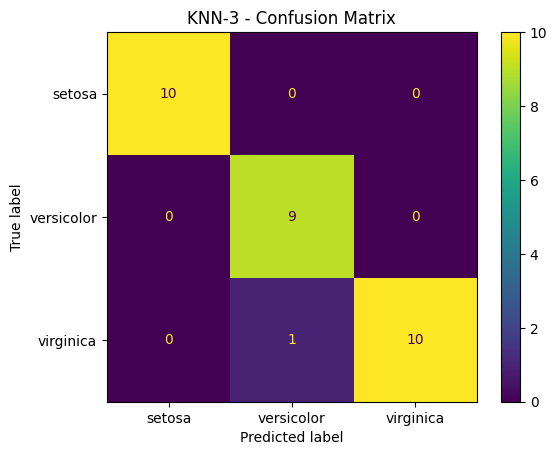

In [51]:
cm = confusion_matrix(y_test, y_pred3)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred3, display_labels=target_names)
plt.title("KNN-3 - Confusion Matrix")
plt.show()

___
## Modeling a Decision Tree on Iris dataset

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_trained_scaled,y_train)

y_pred_dt = dt.predict(X_test)


print(f"Decision Tree Evaluation\n")
print(f"Accuracy: { accuracy_score(y_test, y_pred_dt):.2f}")
print(f"Recall: { recall_score(y_test, y_pred_dt, average="macro"):.2f}")
print(f"F1-Score: { f1_score(y_test, y_pred_dt, average="macro"):.2f}")


Decision Tree Evaluation

Accuracy: 0.37
Recall: 0.33
F1-Score: 0.18
